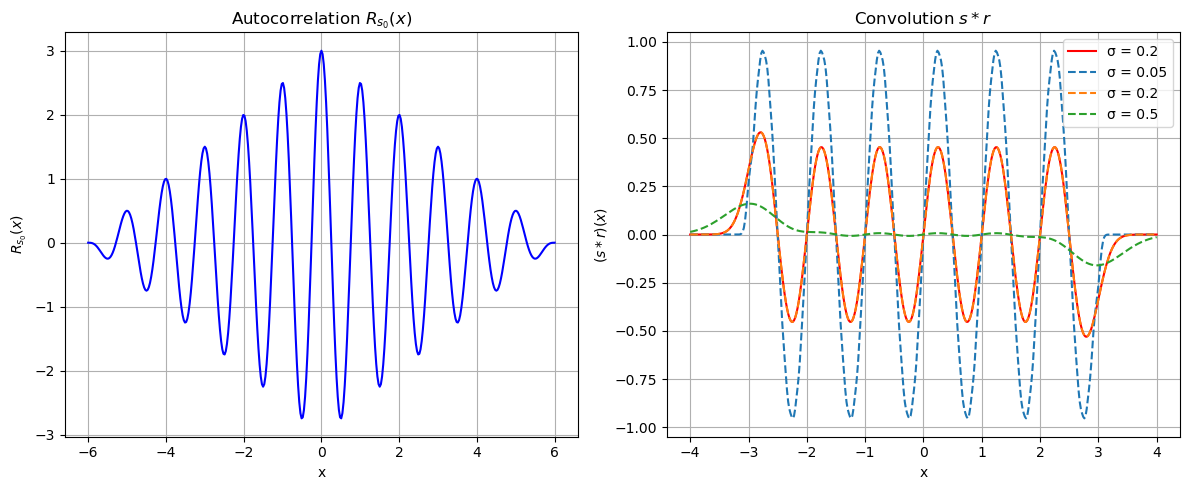

In [1]:
# Compute autocorrelation of s0 and convolution of s with Gaussian kernel, then plot results.
import numpy as np
import matplotlib.pyplot as plt

def s0(x):
    y = np.zeros_like(x)
    mask = (x >= -3) & (x <= 3)
    y[mask] = np.sin(2 * np.pi * x[mask])
    return y

def p(x):
    y = np.zeros_like(x)
    mask = (x >= -3) & (x <= 3)
    y[mask] = np.sin(20 * np.pi * x[mask])
    return y

def s(x):
    return s0(x) + p(x)

def r(x, sigma=0.2):
    return (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-x**2 / (2 * sigma**2))

x_grid = np.linspace(-6, 6, 2001)
x_vals_a = np.linspace(-6, 6, 401)
R_s0 = []
for x in x_vals_a:
    y = x_grid
    integrand = s0(y) * s0(y + x)
    R_s0.append(np.trapz(integrand, y))
R_s0 = np.array(R_s0)

x_vals_b = np.linspace(-4, 4, 401)
sigma = 0.2
conv_sr = []
for x in x_vals_b:
    y = x_grid
    integrand = s(y) * r(x - y, sigma=sigma)
    conv_sr.append(np.trapz(integrand, y))
conv_sr = np.array(conv_sr)

sigmas = [0.05, 0.2, 0.5]
conv_multi = {}
for sig in sigmas:
    conv_multi[sig] = []
    for x in x_vals_b:
        integrand = s(x_grid) * r(x - x_grid, sigma=sig)
        conv_multi[sig].append(np.trapz(integrand, x_grid))
    conv_multi[sig] = np.array(conv_multi[sig])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x_vals_a, R_s0, 'b-', linewidth=1.5)
plt.title(r'Autocorrelation $R_{s_0}(x)$')
plt.xlabel('x')
plt.ylabel(r'$R_{s_0}(x)$')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x_vals_b, conv_sr, 'r-', label=f'σ = {sigma}', linewidth=1.5)
for sig in sigmas:
    plt.plot(x_vals_b, conv_multi[sig], '--', label=f'σ = {sig}')
plt.title(r'Convolution $s * r$')
plt.xlabel('x')
plt.ylabel(r'$(s * r)(x)$')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('hw3_results.png', dpi=300)
plt.show()